## Model 1: Logistic Regression (Baseline)

### Imports

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

### Load data & define features

In [15]:
# Fresh start from original data
df_raw = pd.read_csv("dropout_data.csv")
df_raw = df_raw[df_raw["State/UT"] != "India"].reset_index(drop=True)

# Rename columns cleanly
df_raw.columns = [
    "State",
    "Primary_1920",
    "Primary_2021",
    "Primary_2122",
    "UpperPrimary_1920",
    "UpperPrimary_2021",
    "UpperPrimary_2122",
    "Secondary_1920",
    "Secondary_2021",
    "Secondary_2122",
]

# ← ADD THIS: fill missing values with column median
df_raw = df_raw.fillna(df_raw.median(numeric_only=True))

# Features: Primary + Upper Primary dropout rates across years
X = df_raw[
    [
        "Primary_1920",
        "Primary_2021",
        "Primary_2122",
        "UpperPrimary_1920",
        "UpperPrimary_2021",
        "UpperPrimary_2122",
    ]
]

# Target: Is average Secondary dropout high? (above median)
df_raw["Avg_Secondary"] = df_raw[
    ["Secondary_1920", "Secondary_2021", "Secondary_2122"]
].mean(axis=1)
median_sec = df_raw["Avg_Secondary"].median()
y = (df_raw["Avg_Secondary"] > median_sec).astype(int)

print("Features shape:", X.shape)
print("\nMissing values after fix:", X.isnull().sum().sum())
print("\nTarget distribution:")
print(y.value_counts())
print(f"\nMedian secondary dropout: {median_sec:.2f}%")

Features shape: (37, 6)

Missing values after fix: 0

Target distribution:
Avg_Secondary
0    19
1    18
Name: count, dtype: int64

Median secondary dropout: 4.87%


### Train/Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 29
Test set size: 8


### Train Logistic Regression

In [17]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
print("Model trained!")

Model trained!


### Evaluate

In [18]:
print("=" * 40)
print("   LOGISTIC REGRESSION RESULTS")
print("=" * 40)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

   LOGISTIC REGRESSION RESULTS
Accuracy  : 0.8750
Precision : 1.0000
Recall    : 0.7500
F1 Score  : 0.8571

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.75      0.86         4

    accuracy                           0.88         8
   macro avg       0.90      0.88      0.87         8
weighted avg       0.90      0.88      0.87         8



### Confusion Matrix

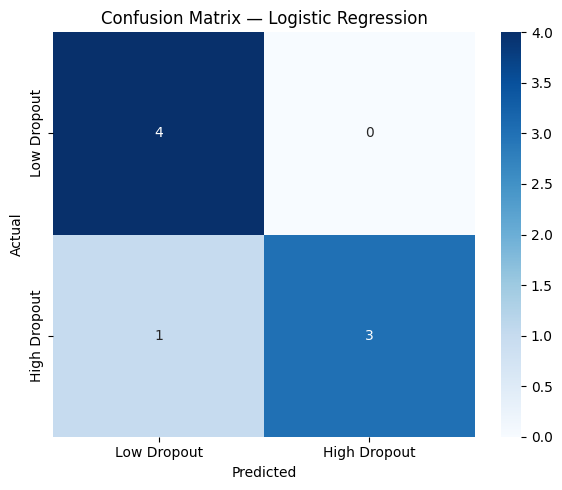

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Dropout", "High Dropout"],
    yticklabels=["Low Dropout", "High Dropout"],
)
plt.title("Confusion Matrix — Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix_lr.png")
plt.show()

### Cross Validation

In [20]:
cv_scores = cross_val_score(lr, X, y, cv=5, scoring="f1")

print("5-Fold Cross Validation F1 Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nMean F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

5-Fold Cross Validation F1 Scores:
  Fold 1: 0.7500
  Fold 2: 1.0000
  Fold 3: 1.0000
  Fold 4: 0.6667
  Fold 5: 0.2857

Mean F1: 0.7405 (+/- 0.2635)


## Day 3 Summary
- Built Logistic Regression baseline model
- Approach: Predict Secondary dropout from Primary + Upper Primary rates
- Accuracy: 87.5% | F1: 85.7% | CV F1: 74% (more reliable with small dataset)
- No data leakage — features and target are independent
- Small dataset (37 states) causes variance in CV scores — expected
- Next: Decision Tree (Day 4)

## Model 2: Decision Tree

### Train Decision Tree

In [21]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree trained!")

Decision Tree trained!


### Evaluate

In [22]:
print("=" * 40)
print("      DECISION TREE RESULTS")
print("=" * 40)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_dt):.4f}")
print()
print(classification_report(y_test, y_pred_dt))

      DECISION TREE RESULTS
Accuracy  : 0.8750
Precision : 1.0000
Recall    : 0.7500
F1 Score  : 0.8571

              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.75      0.86         4

    accuracy                           0.88         8
   macro avg       0.90      0.88      0.87         8
weighted avg       0.90      0.88      0.87         8



### Confusion Matrix

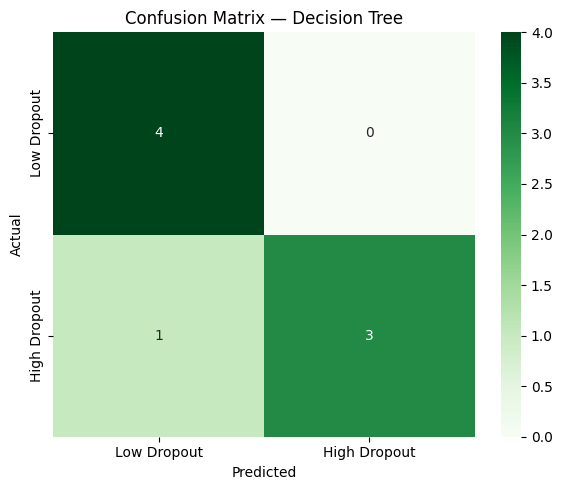

In [23]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Low Dropout", "High Dropout"],
    yticklabels=["Low Dropout", "High Dropout"],
)
plt.title("Confusion Matrix — Decision Tree")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix_dt.png")
plt.show()

### Visualize the Tree 

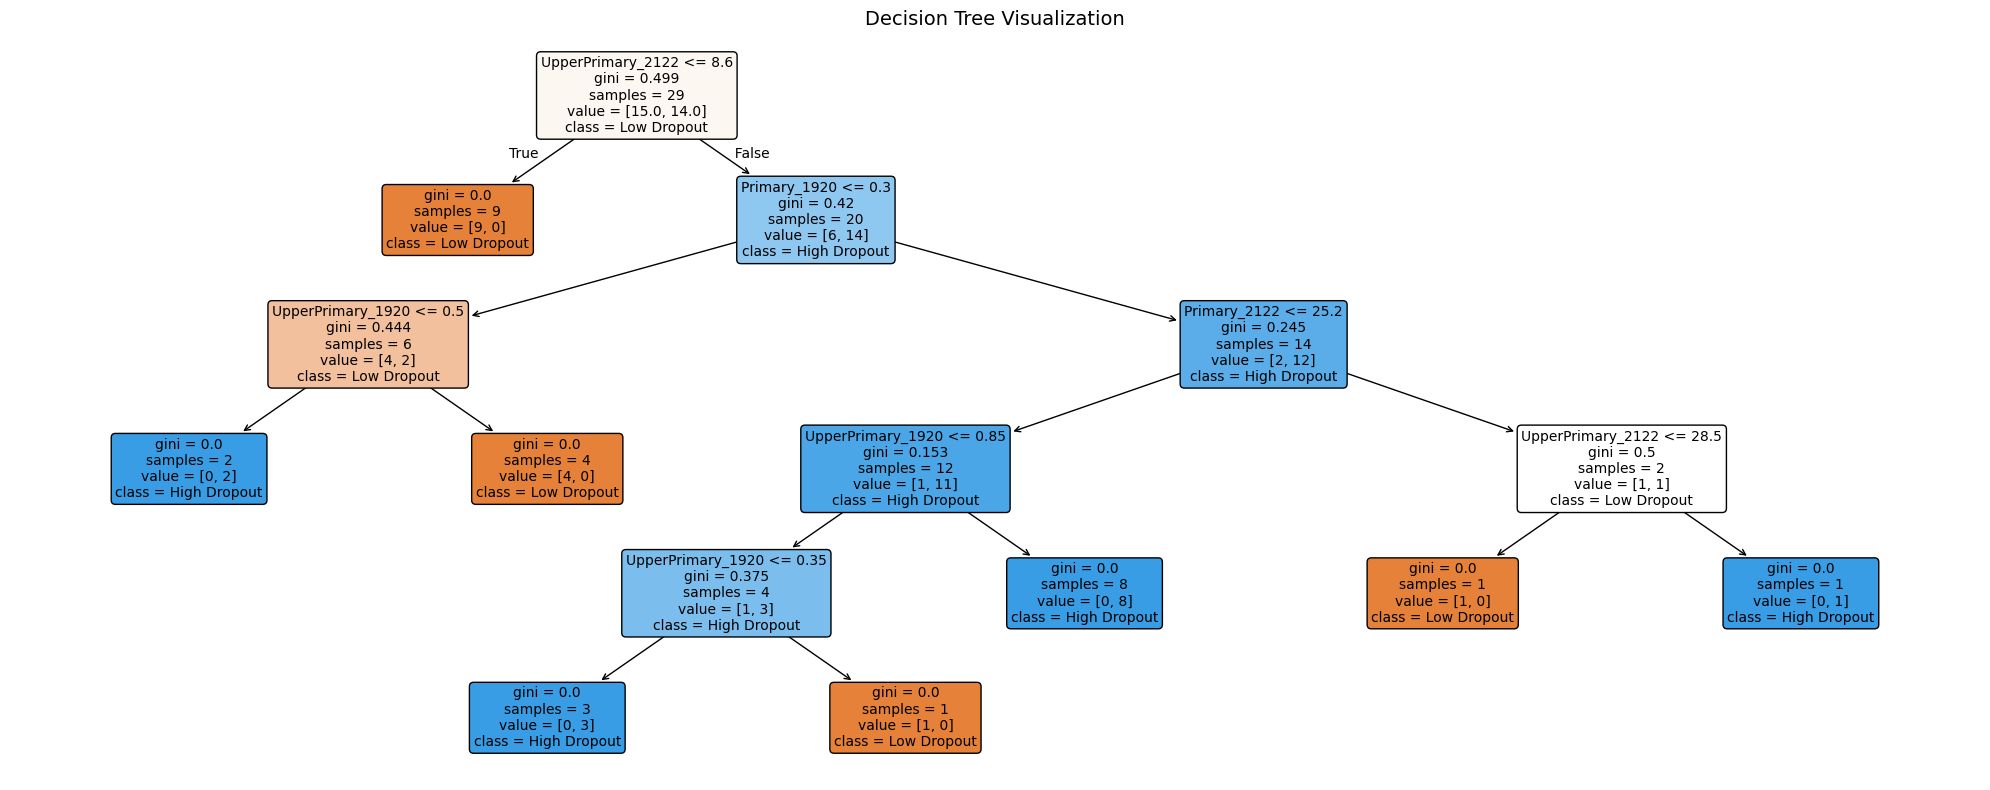

In [24]:
plt.figure(figsize=(20, 8))
plot_tree(
    dt,
    feature_names=[
        "Primary_1920",
        "Primary_2021",
        "Primary_2122",
        "UpperPrimary_1920",
        "UpperPrimary_2021",
        "UpperPrimary_2122",
    ],
    class_names=["Low Dropout", "High Dropout"],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Decision Tree Visualization", fontsize=14)
plt.tight_layout()
plt.savefig("decision_tree_plot.png")
plt.show()

### Cross Validation 

In [25]:
cv_scores_dt = cross_val_score(dt, X, y, cv=5, scoring="f1")

print("5-Fold Cross Validation F1 Scores:")
for i, score in enumerate(cv_scores_dt, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nMean F1 : {cv_scores_dt.mean():.4f} (+/- {cv_scores_dt.std():.4f})")

5-Fold Cross Validation F1 Scores:
  Fold 1: 0.5714
  Fold 2: 0.4000
  Fold 3: 0.8000
  Fold 4: 0.8571
  Fold 5: 0.0000

Mean F1 : 0.5257 (+/- 0.3096)


### Compare LR vs DT so far

              Model  Accuracy  F1 Score    CV F1
Logistic Regression     0.875  0.857143 0.740476
      Decision Tree     0.875  0.857143 0.525714


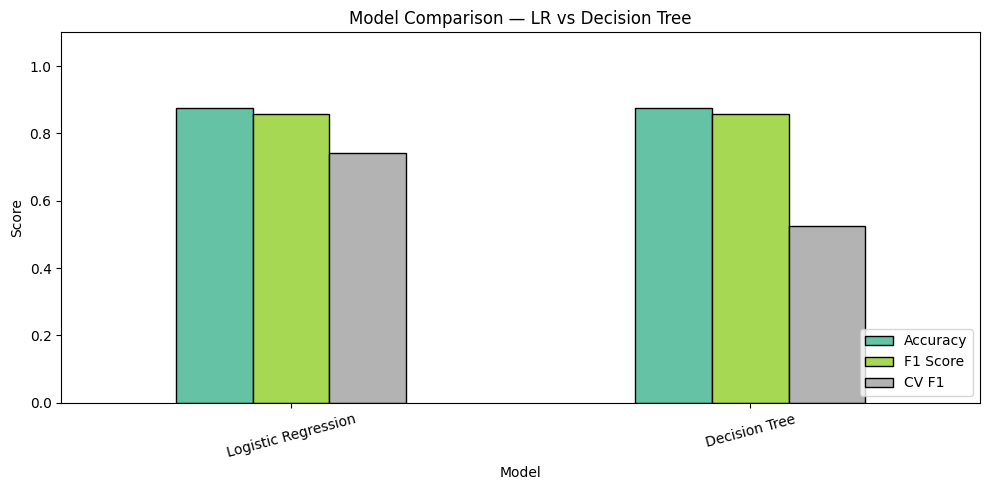

In [26]:
results = {
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_dt)],
    "F1 Score": [f1_score(y_test, y_pred), f1_score(y_test, y_pred_dt)],
    "CV F1": [cv_scores.mean(), cv_scores_dt.mean()],
}

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# Bar chart comparison
df_results.set_index("Model")[["Accuracy", "F1 Score", "CV F1"]].plot(
    kind="bar", figsize=(10, 5), colormap="Set2", edgecolor="black"
)
plt.title("Model Comparison — LR vs Decision Tree")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1.1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("model_comparison.png")
plt.show()

## Day 4 Summary
- Built Decision Tree model
- Visualized the full tree — shows exact decision rules
- Compared with Logistic Regression using Accuracy, F1 and CV F1
- Next: Random Forest (Day 5) — combines many trees for better accuracy
- Decision Tree overfits (CV F1: 52.6% vs LR's 74%) — 
  Random Forest fixes this by averaging many trees

## Model 3: Random Forest

### Train Random Forest

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest trained!")

Random Forest trained!


### Evaluate

In [28]:
print("=" * 40)
print("      RANDOM FOREST RESULTS")
print("=" * 40)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_rf):.4f}")
print()
print(classification_report(y_test, y_pred_rf))

      RANDOM FOREST RESULTS
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



### Confusion Matrix

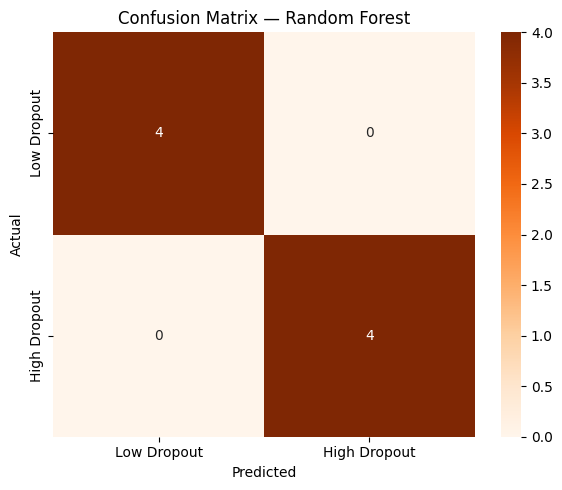

In [29]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Low Dropout", "High Dropout"],
    yticklabels=["Low Dropout", "High Dropout"],
)
plt.title("Confusion Matrix — Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix_rf.png")
plt.show()

### Feature Importance

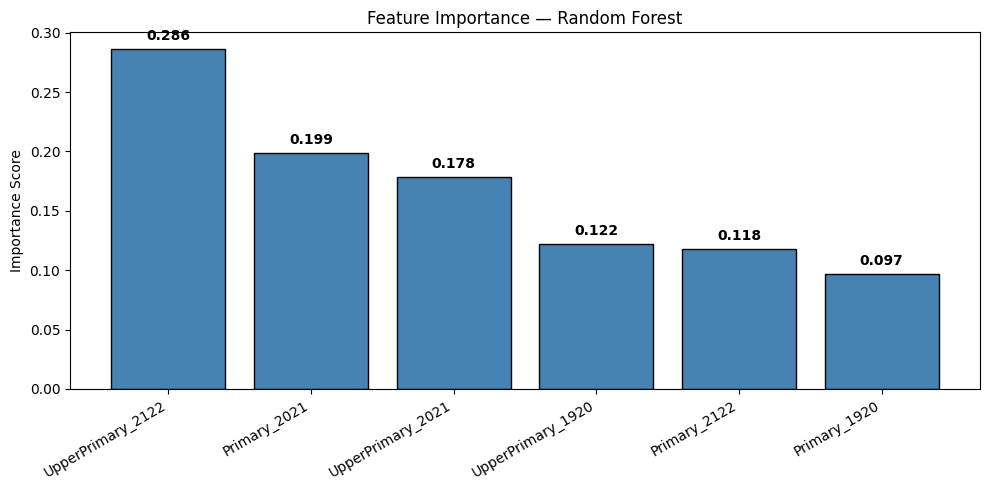


Top feature: UpperPrimary_2122
This means: this year/level's dropout rate is most predictive of secondary dropout


In [30]:
feature_names = [
    "Primary_1920",
    "Primary_2021",
    "Primary_2122",
    "UpperPrimary_1920",
    "UpperPrimary_2021",
    "UpperPrimary_2122",
]

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
bars = plt.bar(
    range(len(feature_names)),
    importances[indices],
    color="steelblue",
    edgecolor="black",
)

# Add value labels on bars
for bar, imp in zip(bars, importances[indices]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{imp:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

plt.xticks(
    range(len(feature_names)),
    [feature_names[i] for i in indices],
    rotation=30,
    ha="right",
)
plt.title("Feature Importance — Random Forest")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance_rf.png")
plt.show()

print("\nTop feature:", feature_names[indices[0]])
print(
    "This means: this year/level's dropout rate is most predictive of secondary dropout"
)

### Cross Validation

In [31]:
cv_scores_rf = cross_val_score(rf, X, y, cv=5, scoring="f1")

print("5-Fold Cross Validation F1 Scores:")
for i, score in enumerate(cv_scores_rf, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nMean F1 : {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")

5-Fold Cross Validation F1 Scores:
  Fold 1: 0.8889
  Fold 2: 0.6667
  Fold 3: 1.0000
  Fold 4: 0.8000
  Fold 5: 0.3333

Mean F1 : 0.7378 (+/- 0.2298)


### 3-model comparison

              Model  Accuracy  F1 Score    CV F1
Logistic Regression     0.875  0.857143 0.740476
      Decision Tree     0.875  0.857143 0.525714
      Random Forest     1.000  1.000000 0.737778


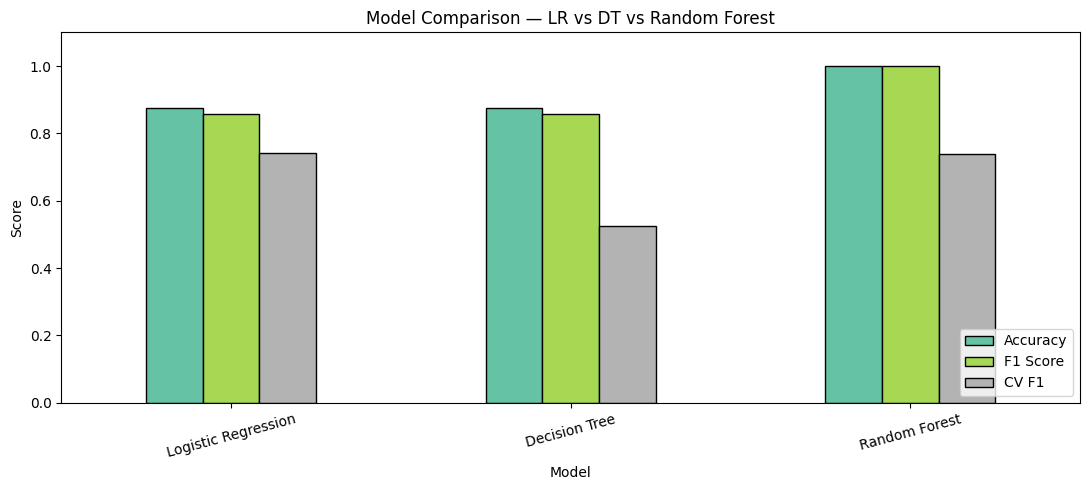

In [32]:
results = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
    ],
    "CV F1": [cv_scores.mean(), cv_scores_dt.mean(), cv_scores_rf.mean()],
}

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# Bar chart
df_results.set_index("Model")[["Accuracy", "F1 Score", "CV F1"]].plot(
    kind="bar", figsize=(11, 5), colormap="Set2", edgecolor="black"
)
plt.title("Model Comparison — LR vs DT vs Random Forest")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1.1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("model_comparison.png")
plt.show()

## Day 5 Summary
- Built Random Forest (100 trees, random_state=42)
- CV F1: 73.8% — matches Logistic Regression, far better than Decision Tree
- Top predictive feature: Upper Primary 2021-22 dropout rate
- Key insight: The level just before Secondary is the strongest early warning signal
- Random Forest fixes DT overfitting: DT CV F1 (52.6%) → RF CV F1 (73.8%)
- Next: XGBoost — Day 6 (industry standard model)